# AML 3303 — Week 3 In-Class Lab (30 minutes)
### pandas + NumPy only

## Scenario

**NorthLine Electronics** is an online store. The ops team exported two tables for you:
`customers` and `orders`. They want a quick read on which product categories actually
make money, and which city orders the most.

The export is realistic, which means it is slightly messy: a missing quantity, a missing
price, a duplicate order, and one order from a customer who is not in the customer list.

Fill in every cell marked `# TODO`. The hints sit directly above each one.

## 0. Setup

Run this cell once. Do not change it.

In [1]:
# Run this cell first. It creates the two DataFrames you will work with.
import pandas as pd
import numpy as np

customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "name": ["Aarav Shah","Bianca Rossi","Chen Wei","Diya Patel",
             "Emeka Obi","Farah Haddad","Grace Kim","Hugo Martin"],
    "city": ["Ottawa","Toronto","Ottawa","Montreal",
             "Toronto","Calgary","Montreal","Ottawa"],
})

orders = pd.DataFrame({
    "order_id":   [101,102,103,104,105,106,107,108,109,110,
                   111,112,113,114,115,116,117,118,119,120,118,121],
    "customer_id":[  1,  2,  1,  3,  4,  5,  2,  6,  3,  7,
                     8,  5,  1,  4,  6,  7,  2,  8,  3,  5,  8,  9],
    "order_date": ["2024-05-02","2024-05-02","2024-05-04","2024-05-05","2024-05-07",
                   "2024-05-08","2024-05-09","2024-05-11","2024-05-12","2024-05-13",
                   "2024-05-15","2024-05-16","2024-05-18","2024-05-19","2024-05-20",
                   "2024-05-22","2024-05-23","2024-05-25","2024-05-26","2024-05-28",
                   "2024-05-25","2024-05-29"],
    "category":   ["Laptops","Headphones","Headphones","Monitors","Laptops",
                   "Keyboards","Monitors","Laptops","Keyboards","Headphones",
                   "Monitors","Laptops","Keyboards","Headphones","Monitors",
                   "Laptops","Keyboards","Headphones","Laptops","Monitors",
                   "Headphones","Keyboards"],
    "quantity":   [1,2,1,2,1,3,1,1,np.nan,1,4,1,2,1,1,1,1,2,1,2,2,1],
    "unit_price": [1299.99,89.50,89.50,219.00,1499.00,45.00,219.00,1099.00,45.00,np.nan,
                   219.00,1299.99,45.00,89.50,219.00,1499.00,45.00,89.50,1299.99,219.00,
                   89.50,45.00],
    "status":     ["delivered","delivered","returned","delivered","cancelled",
                   "delivered","delivered","delivered","delivered","delivered",
                   "delivered","returned","delivered","delivered","delivered",
                   "delivered","cancelled","delivered","delivered","delivered",
                   "delivered","delivered"],
})

print("orders:", orders.shape, " customers:", customers.shape)
orders.head()

orders: (22, 7)  customers: (8, 3)


,order_id,customer_id,order_date,category,quantity,unit_price,status
0,101,1,2024-05-02,Laptops,1.0,1299.99,delivered
1,102,2,2024-05-02,Headphones,2.0,89.50,delivered
2,103,1,2024-05-04,Headphones,1.0,89.50,returned
3,104,3,2024-05-05,Monitors,2.0,219.00,delivered
4,105,4,2024-05-07,Laptops,1.0,1499.00,cancelled


## 1. First look (3 min)

**Hints**
- `df.shape` → rows and columns
- `df.info()` → column types and non-null counts
- `df.describe()` → quick numeric summary
- `df["category"].value_counts()` → how many orders per category

In [2]:
print("shape:", orders.shape, orders.info())

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     22 non-null     int64  
 1   customer_id  22 non-null     int64  
 2   order_date   22 non-null     str    
 3   category     22 non-null     str    
 4   quantity     21 non-null     float64
 5   unit_price   21 non-null     float64
 6   status       22 non-null     str    
dtypes: float64(2), int64(2), str(3)
memory usage: 1.3 KB
shape: (22, 7) None


In [3]:
print("orders per category")

orders per category


## 2. A first (wrong) answer (5 min)

Compute revenue per category **before** cleaning anything, counting delivered orders only.
Keep this result: you will compare against it at the end.

**Hints**
- Filter rows: `orders[orders["status"] == "delivered"]`
- New column: `df["revenue"] = df["quantity"] * df["unit_price"]`
- Group: `df.groupby("category")["revenue"].sum().sort_values(ascending=False)`

category
Headphones     626.50
Keyboards      270.00
Laptops       5197.98
Monitors      2190.00
Name: revenue, dtype: float64


<Axes: title={'center': 'Revenue by Category (Raw Orders)'}, xlabel='category'>

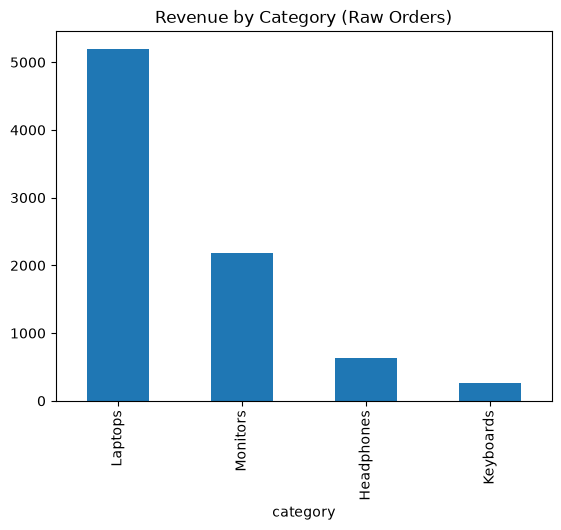

In [14]:
# TODO: revenue by category using the RAW orders (delivered only)
delivered = orders.loc[orders['status'] == 'delivered'].assign(
	revenue=lambda df: df['quantity'] * df['unit_price']
)
revenue_raw = delivered.groupby('category')['revenue'].sum()
print(revenue_raw)
revenue_raw.sort_values(ascending=False).plot(kind='bar', title='Revenue by Category (Raw Orders)')

## 3. Find the problems (5 min)

**Hints**
- Duplicates: `df.duplicated().sum()`, and `df[df.duplicated(keep=False)]` to see them
- Missing values: `df.isna().sum()`
- Orphan rows: `~orders["customer_id"].isin(customers["customer_id"])`

In [7]:
# TODO: 1. how many fully duplicated rows are there? Show them.
df_duplicates = orders[orders.duplicated(keep=False)]
print("Number of fully duplicated rows:", len(df_duplicates))
print("Duplicated rows:")
print(df_duplicates)

# TODO: 2. how many missing values in each column?
print("Missing values in each column:")
print(orders.isnull().sum())

# TODO: 3. which orders belong to a customer who is NOT in the customers table?
df_missing_customers = orders[~orders['customer_id'].isin(customers['customer_id'])]
print("Orders with missing customers:")
print(df_missing_customers)

Number of fully duplicated rows: 2
Duplicated rows:
    order_id  customer_id  order_date    category  quantity  unit_price  \
17       118            8  2024-05-25  Headphones       2.0        89.5   
20       118            8  2024-05-25  Headphones       2.0        89.5   

       status  
17  delivered  
20  delivered  
Missing values in each column:
order_id       0
customer_id    0
order_date     0
category       0
quantity       1
unit_price     1
status         0
dtype: int64
Orders with missing customers:
    order_id  customer_id  order_date   category  quantity  unit_price  \
21       121            9  2024-05-29  Keyboards       1.0        45.0   

       status  
21  delivered  


## 4. Clean it (7 min)

**Hints**
- `orders_clean = orders.drop_duplicates()`
- Fill a price with the median for that category:
  `df.groupby("category")["unit_price"].transform("median")`
- `df["quantity"].fillna(1)` — one unit is a reasonable default for this shop
- `pd.to_datetime(df["order_date"])`
- Make quantity an integer at the end: `.astype(int)`

In [8]:
orders_clean = orders.copy()

# TODO: 1. drop duplicate rows
orders_clean = orders_clean.drop_duplicates()

# TODO: 2. fill missing unit_price with the median price of the same category
orders_clean['unit_price'] = orders_clean.groupby('category')['unit_price'].transform(lambda x: x.fillna(x.median()))

# TODO: 3. fill missing quantity with 1, then convert the column to int
orders_clean['quantity'] = orders_clean['quantity'].fillna(1)
orders_clean['quantity'] = orders_clean['quantity'].astype(int)


# TODO: 4. convert order_date to datetime
orders_clean['order_date'] = pd.to_datetime(orders_clean['order_date'])

orders_clean.info()

<class 'pandas.DataFrame'>
Index: 21 entries, 0 to 21
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     21 non-null     int64         
 1   customer_id  21 non-null     int64         
 2   order_date   21 non-null     datetime64[us]
 3   category     21 non-null     str           
 4   quantity     21 non-null     int64         
 5   unit_price   21 non-null     float64       
 6   status       21 non-null     str           
dtypes: datetime64[us](1), float64(1), int64(3), str(2)
memory usage: 1.7 KB


## 5. NumPy: revenue column (3 min)

Cancelled and returned orders earn **no** revenue.

**Hints**
- `np.where(condition, value_if_true, value_if_false)`
- Condition: `orders_clean["status"] == "delivered"`
- `np.round(x, 2)` if you want tidy numbers

In [9]:
# TODO: create a "revenue" column that is 0 for cancelled and returned orders
orders_clean["revenue"] = orders_clean.apply(lambda row: row["quantity"] * row["unit_price"] if row["status"] == "delivered" else 0, axis=1)

# TODO: print total revenue, the mean order value, and the largest single order
print("Total revenue:", orders_clean["revenue"].sum())
print("Mean order value:", orders_clean["revenue"].mean())
print("Largest single order:", orders_clean["revenue"].max())


Total revenue: 8239.98
Mean order value: 392.38
Largest single order: 1499.0


## 6. Merge and answer the business question (5 min)

**Hints**
- `orders_clean.merge(customers, on="customer_id", how="left")`
- A left merge keeps the order from the unknown customer, with `city` as NaN. That is
  usually what you want: do not silently delete money.
- `.groupby("city")["revenue"].sum().sort_values(ascending=False)`

In [10]:
# TODO: merge customers into orders_clean, then find revenue by city
merged_df = pd.merge(orders_clean, customers, on='customer_id', how='left')

revenue_by_city = merged_df.groupby('city')['revenue'].sum()
revenue_by_city

city
Calgary     1318.00
Montreal    1678.00
Ottawa      4227.98
Toronto      971.00
Name: revenue, dtype: float64

## 7. Compare with step 2 (2 min)

**Hint:** `pd.DataFrame({"raw": revenue_raw, "clean": revenue_clean})` lines the two up side by side.

In [ ]:
# TODO: revenue by category from the CLEANED data, then compare it with revenue_raw
revenue_clean = orders_clean.groupby('category')['revenue'].sum()


comparison = pd.DataFrame({'Cleaned': revenue_clean, 'Raw': revenue_raw})
comparison

,Cleaned,Raw
category,,
Headphones,537.00,626.50
Keyboards,315.00,270.00
Laptops,5197.98,5197.98
Monitors,2190.00,2190.00


**Question:** two categories changed. Which ones, and what caused each change?

*Your answer:* Headphones and Keyboards changed, Both totals dropped because rows with missing or blank quantity values were removed during cleaning, which eliminated one Headphones sale ($89.50) and one Keyboard sale ($45.00)



## 8. Wrap up (optional, if time)

Write two sentences for the NorthLine ops team: which category to push, and one data
quality issue they should fix at the source.

*Your answer:*

---

### Submission
Save the notebook, push it to your GitHub repo, and paste the repo link in the class channel.

### Stretch goals
1. Which customer spent the most? (merge, then group by name)
2. Add a `week` column from `order_date` and show revenue per week.
   Hint: `df["order_date"].dt.isocalendar().week`
3. Ask Claude or Copilot to write the cleaning step for you, then compare it with yours.
   Did it make the same choices about the missing quantity? Was it right?